# SatGen vs Galacticus: subhalo stripping in a $10^8\,M_\odot$ host

Compare two SatGen stripping prescriptions against a full-evolution Galacticus run
(one merger tree, single host $M_\mathrm{vir}=10^8\,M_\odot$ at $z=0$, subhalos dumped
across $z=10\to0$). Each subhalo's concentration $c=r_\mathrm{vir}/r_s$ is read straight
from Galacticus (`darkMatterOnlyRadiusVirial / darkMatterProfileScale`).

We pick a few representative subhalos accreted at different redshifts and evolve each from
infall to $z=0$ under two methods, then line them up against the Galacticus run:

- **Green/DASH** — Zentner+05 mass stripping (King62 $y_c=1$ tidal radius) per timestep, then
  Green & van den Bosch 2019 transfer function (`evolve_satgen_green`, concentration-dependent
  stripping efficiency).
- **Du+24 `truncation=hard`, $y_c=0$** — shell heating with a hard tidal-radius truncation
  (`evolve_heating`, `truncation='hard'`, `lt='Tormen98'`, second order). Parameters set
  in the next cell from our own MCMC calibration agains N-GADGET and DASH N-body simulations.

The host is held static at each subhalo's infall-redshift host values $(M_\mathrm{vir}, r_s)$.
Galacticus carries $m_\mathrm{bound}$ as a scalar ledger with no structural evolution (plain
frozen NFW + a van den Bosch 2005 mass-loss rate; no tidal heating in this run), so
$m_\mathrm{bound}(t)$ and orbital $r(t)$ are direct truth; a Galacticus *tidal track* is only
a reference, its $m_\mathrm{bound}$ history mapped through the Penarrubia+2010 relation.

The data file (`galacticus_subhalos.hdf5`) is assumed present in this directory but is gitignored.

In [1]:
import os, sys
import numpy as np
import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 13
import matplotlib.pyplot as plt

# config.py loads etc/*.npy relative to cwd, so chdir to the repo root one level
# up (like the other scripts). Keep this dir (HERE) on sys.path to import the
# engine module and to hold the run cache.
HERE = os.getcwd()
sys.path.insert(0, HERE)
os.chdir(os.path.join(HERE, '..'))

import config as cfg
cfg.Mres = 0.1     # 1e8 host is 1e-4 of the usual 1e12; scale Mres from 1e3
# Length scales here are ~20x smaller than the 1e12/1e9 Du+24 fiducial (host
# rvir ~10 kpc, subhalo rs ~0.02-0.1 kpc, smallest data pericenters ~2e-3 kpc),
# so push Rres below the default 1e-3 to stay ~100x clear of every scale and
# resolve the deep end of the structural tracks. The clean nodes here are
# insensitive to this (peri >> Rres, rmax_min ~0.02 kpc): results are identical
# to <0.3% over Rres = 1e-3 ... 1e-6.
cfg.Rres = 1e-5

import galacticus_subhalo_evolution as gc

# Du+24 hard (yc0) heating params: posterior median of a joint Du+24 + DASH
# hard-truncation calibration (truncation='hard', lt='Tormen98'). Frozen here so
# this notebook is self-contained.
HARD = {
    'alpha_s': 1.860269,
    'eps_h':   0.254772,
    'beta_h':  3.867699,
    'f_2':     0.363113,
    'gamma_h': 0.001856,
}


def fmt_pow10(m, sig=1):
    """LaTeX a x 10^b for clean mathtext titles (avoids the '6.4e+06' spacing)."""
    e = int(np.floor(np.log10(m)))
    return rf"{m/10**e:.{sig}f}\times10^{{{e}}}"


G = gc.Galacticus()
print("Du+24 hard (yc0) params:")
for k, v in HARD.items():
    print(f"  {k:8s} {v:.4f}")
print(f"\nsnapshots: {len(G.z)}  z {G.z.min():.2f}-{G.z.max():.2f}  t {G.t.min():.2f}-{G.t.max():.2f} Gyr")
print(f"cfg.Mres={cfg.Mres}  cfg.Rres={cfg.Rres} kpc")

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


Du+24 hard (yc0) params:
  alpha_s  1.8603
  eps_h    0.2548
  beta_h   3.8677
  f_2      0.3631
  gamma_h  0.0019

snapshots: 5000  z 0.00-10.00  t 0.47-13.79 Gyr
cfg.Mres=0.1  cfg.Rres=1e-05 kpc


## Which Galacticus stripping prescription?

Read straight from the output's parameter tree (cell below): this run strips via
`darkMatterHaloMassLossRate = vanDenBosch` — the **van den Bosch, Tormen & Giocoli (2005)**
orbit-averaged subhalo mass-loss rate, **not** a King62/Zentner+05 tidal-radius prescription
(no `satelliteTidalStripping` operator is present in the file):

$$\dot{m}_\mathrm{bound} = -\frac{m_\mathrm{bound}}{\tau}\left(\frac{m_\mathrm{bound}}{M_\mathrm{host}}\right)^{\zeta},
\qquad
\tau = \tau_0\left(\frac{\Delta_\mathrm{vir}(t)}{\Delta_\mathrm{vir}(t_0)}\right)^{-1/2} a^{3/2},$$

with $\tau_0 = 0.13$ Gyr and $\zeta = 0.36$. The timescale $\tau\propto\langle\rho_\mathrm{vir}\rangle^{-1/2}$
is the virial dynamical time — a function of redshift only (normalized to $\tau_0$ at $z=0$),
with no tidal radius and no dependence on the subhalo's orbital position.

In [2]:
import h5py
with h5py.File(gc.HDF5, 'r') as _f:
    par = _f['Parameters']
    mlr_class = par.attrs['darkMatterHaloMassLossRate']
    mlr_class = mlr_class.decode() if isinstance(mlr_class, bytes) else mlr_class
    mlr_par = dict(par['darkMatterHaloMassLossRate'].attrs)
    has_zentner = 'satelliteTidalStripping' in par
print(f"darkMatterHaloMassLossRate = {mlr_class!r}")
print(f"  rate params: tau_0 = {mlr_par['timescaleNormalization']} Gyr,  zeta = {mlr_par['zeta']}")
print(f"satelliteTidalStripping (King62/Zentner05) present: {has_zentner}")

darkMatterHaloMassLossRate = 'vanDenBosch'
  rate params: tau_0 = 0.13 Gyr,  zeta = 0.36
satelliteTidalStripping (King62/Zentner05) present: False


## Pick representative subhalos

From the $z=0$ satellites, keep ones with infall $M_\mathrm{vir}>10^5\,M_\odot$ (resolved)
that are actually stripped but still alive ($10^{-3}<f_b<0.9$), and that start near the
host virial radius at infall (clean infallers, not backsplash). The five we evolve are
marked `<--` in the table below; node 3034 ($z_\mathrm{inf}=7.45$) sits just under the
$10^5\,M_\odot$ cut but is the earliest resolved survivor, so it's included explicitly.

In [3]:
# five subhalos spread across infall redshift; 4/16/30/46 are clean infallers
# (r0 ~ rvir), 3034 is the earliest resolved survivor (z_inf=7.15, M_inf~9e4,
# sampled a bit inside rvir). Earlier z=10 infallers are all ~1e4 Msun, too noisy.
NODES = [4, 16, 30, 46, 3034]

# z=0 satellites: the resolved, stripped-but-alive candidate pool, plus our
# picks (marked) even when they fall just outside the cut (node 3034: M_inf<1e5)
s0 = G.snaps[0]
sub = np.where(s0['nodeIsIsolated'] == 0)[0]
rows = []
for j in sub:
    nid = int(s0['nodeIndex'][j])
    Minf = float(s0['basicMass'][j]); Mfin = float(s0['satelliteBoundMass'][j])
    zi = G.z[np.argmin(np.abs(G.t - s0['basicTimeLastIsolated'][j]))]
    if (Minf > 1e5 and 1e-3 < Mfin/Minf < 0.9) or nid in NODES:
        rows.append((nid, zi, Minf, Mfin, Mfin/Minf))
rows.sort(key=lambda r: r[1])
print(" node   z_inf   Minf       Mfin       f_b      r0/rvir  pick")
for nid, zi, Minf, Mfin, fb in rows:
    ic = gc.infall_ics(G, nid)
    mark = '  <--' if nid in NODES else ''
    print(f" {nid:5d}  {zi:5.2f}  {Minf:.2e}  {Mfin:.2e}  {fb:.4f}   {ic['r0']/ic['rvir_host']:.2f}{mark}")

 node   z_inf   Minf       Mfin       f_b      r0/rvir  pick
     4   0.13  6.41e+06  3.39e+05  0.0529   0.94  <--
    10   0.45  2.56e+05  1.33e+04  0.0518   0.98
    16   0.59  1.29e+06  1.23e+04  0.0096   0.95  <--
    20   0.71  3.98e+05  6.87e+03  0.0172   0.97
    22   0.76  2.85e+06  8.48e+03  0.0030   0.96
  8103   0.81  1.57e+05  3.30e+03  0.0210   0.93
  5243   1.00  1.01e+05  2.33e+03  0.0231   1.65
    30   1.91  2.28e+05  9.12e+02  0.0040   0.95  <--
  5255   2.01  3.10e+05  5.45e+02  0.0018   0.61
    46   3.26  1.22e+05  3.52e+02  0.0029   0.97  <--
  3034   7.47  9.04e+04  1.01e+02  0.0011   0.92  <--


## Run the evolutions

Green/DASH and Du+24+hard-truncation, infall $\to z=0$, static infall-host. Step count is sized so $\Delta t\sim0.0015$ Gyr.

In [4]:
import pickle

# cache RUNS keyed on (data file, nodes, params, Mres, Rres) so plot-only edits
# don't recompute the evolutions. The data file enters via path + size so swapping
# the hdf5 invalidates automatically; still delete the cache after editing
# galacticus_subhalo_evolution.run_node.
CACHE = os.path.join(HERE, 'galacticus_runs_cache.pkl')
sig = (gc.HDF5, os.path.getsize(gc.HDF5), tuple(NODES),
       tuple(sorted(HARD.items())), cfg.Mres, cfg.Rres)

RUNS = None
if os.path.exists(CACHE):
    with open(CACHE, 'rb') as fh:
        cached = pickle.load(fh)
    if cached.get('sig') == sig:
        RUNS = cached['runs']
        print(f"loaded cached RUNS from {CACHE}")
if RUNS is None:
    RUNS = {nid: gc.run_node(G, nid, HARD) for nid in NODES}
    with open(CACHE, 'wb') as fh:
        pickle.dump({'sig': sig, 'runs': RUNS}, fh)
    print(f"computed RUNS and cached to {CACHE}")

def ff(r):
    m = r.m[np.isfinite(r.m)]; return m[-1] / m[0]
for nid in NODES:
    o = RUNS[nid]; ic = o['ic']
    print(f"node {nid:5d}  z_inf={ic['z']:.2f}  tmax={ic['tmax']:4.1f} Gyr  c_sub={ic['c_sub']:4.1f}  "
          f"nstep={o['nstep']:6d} | final f_b  green={ff(o['green']):.2e}  "
          f"hard={ff(o['hard']):.2e}  gal={o['gal']['m_over_m0'][-1]:.2e}")

loaded cached RUNS from /Users/fabiokung/code/research/SatGen/analysis/galacticus_runs_cache.pkl
node     4  z_inf=0.13  tmax= 1.7 Gyr  c_sub=46.9  nstep=  1149 | final f_b  green=7.46e-01  hard=5.69e-01  gal=5.29e-02
node    16  z_inf=0.59  tmax= 5.8 Gyr  c_sub=33.6  nstep=  3891 | final f_b  green=7.65e-01  hard=7.55e-01  gal=9.56e-03
node    30  z_inf=1.91  tmax=10.4 Gyr  c_sub= 7.9  nstep=  6912 | final f_b  green=3.68e-02  hard=6.16e-02  gal=4.00e-03
node    46  z_inf=3.26  tmax=11.8 Gyr  c_sub= 4.1  nstep=  7894 | final f_b  green=2.15e-04  hard=9.72e-02  gal=2.89e-03
node  3034  z_inf=7.45  tmax=13.1 Gyr  c_sub= 4.3  nstep=  8728 | final f_b  green=1.00e-05  hard=4.48e-03  gal=1.12e-03


## Mass loss: $m_\mathrm{bound}(t)$

Bound mass relative to infall vs time since infall.

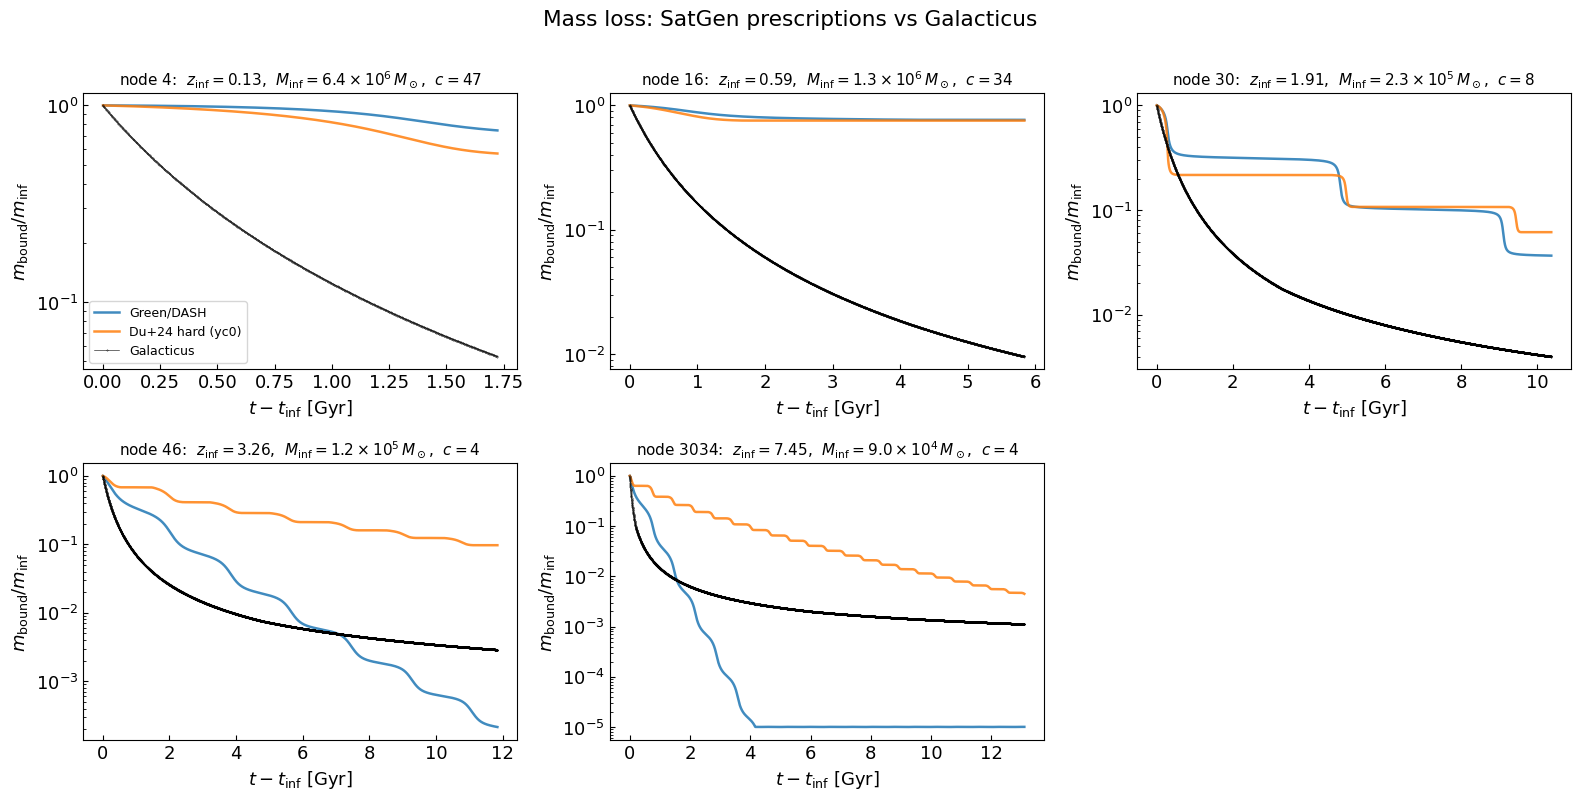

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; ic = o['ic']
    for r, c, lab in [(o['green'], 'C0', 'Green/DASH'), (o['hard'], 'C1', 'Du+24 hard (yc0)')]:
        g = np.isfinite(r.t) & np.isfinite(r.m)
        ax.plot(r.t[g], r.m[g]/r.m[g][0], color=c, lw=1.8, alpha=0.85, label=lab)
    gal = o['gal']
    ax.plot(gal['t_anchor'], gal['m_anchor'], 'k.-', ms=0.5, lw=0.4, label='Galacticus')
    ax.set_yscale('log')
    ax.set_title(f"node {nid}:  $z_\\mathrm{{inf}}={ic['z']:.2f}$,  "
                 f"$M_\\mathrm{{inf}}={fmt_pow10(ic['Mvir'])}\\,M_\\odot$,  $c={ic['c_sub']:.0f}$",
                 fontsize=11)
    ax.set_xlabel('$t - t_\\mathrm{inf}$ [Gyr]'); ax.set_ylabel('$m_\\mathrm{bound}/m_\\mathrm{inf}$')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=9)
fig.suptitle('Mass loss: SatGen prescriptions vs Galacticus', y=1.0)
fig.tight_layout()
plt.show()

## Orbital radius: $r(t)$

Probes the dynamical-friction implementation. The static infall-host potential differs from Galacticus's growing host, so orbit offsets are expected for the early infallers.

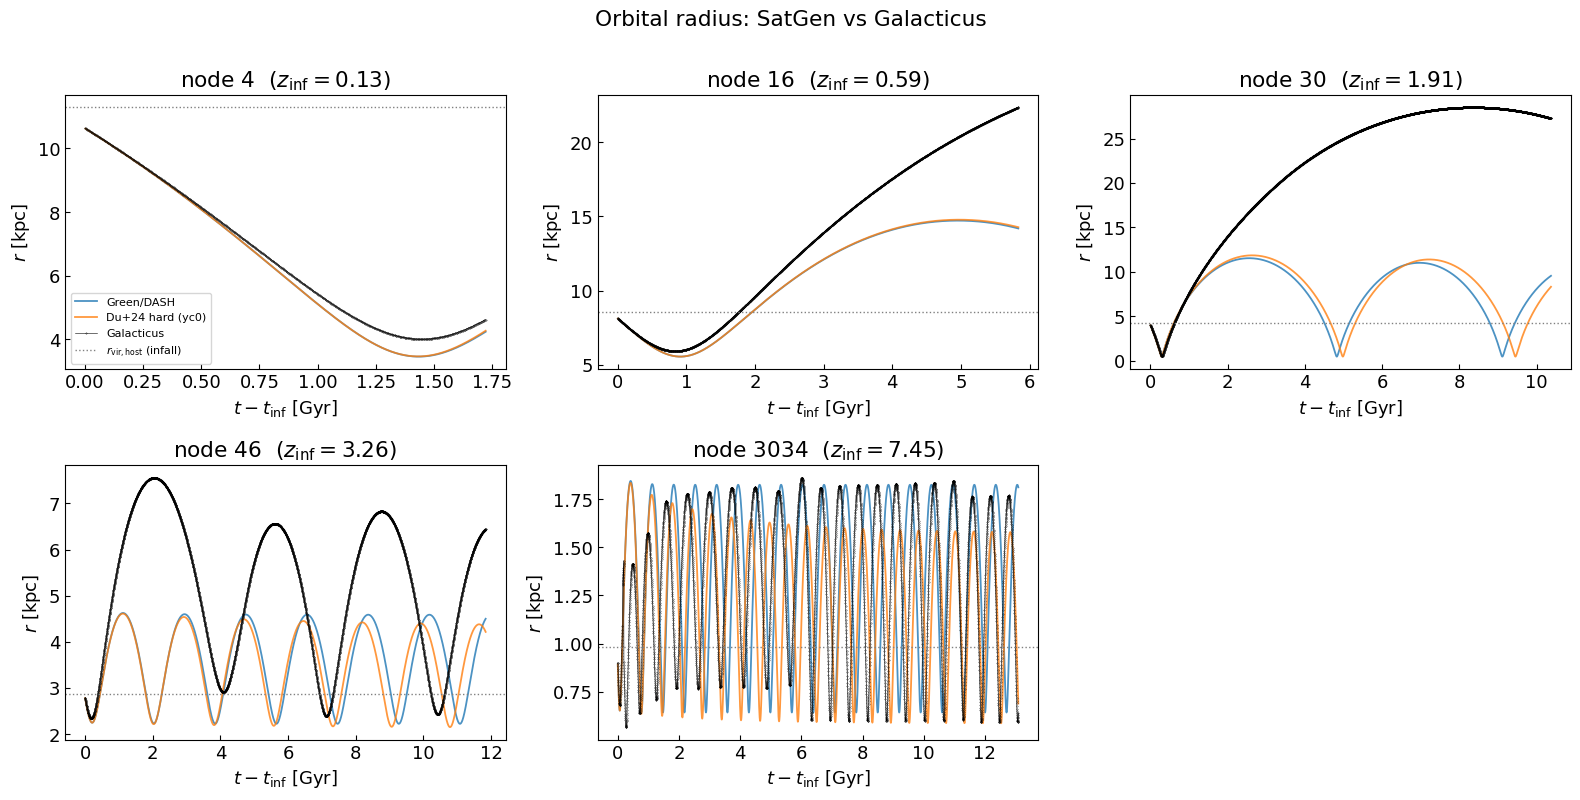

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; ic = o['ic']
    for r, c, lab in [(o['green'], 'C0', 'Green/DASH'), (o['hard'], 'C1', 'Du+24 hard (yc0)')]:
        g = np.isfinite(r.t) & np.isfinite(r.r)
        ax.plot(r.t[g], r.r[g], color=c, lw=1.3, alpha=0.8, label=lab)
    gal = o['gal']
    ax.plot(gal['t_orb'], gal['r_orb'], 'k.-', ms=0.5, lw=0.4, label='Galacticus')
    ax.axhline(ic['rvir_host'], color='gray', ls=':', lw=1, label='$r_\\mathrm{vir,host}$ (infall)')
    ax.set_title(f"node {nid}  ($z_\\mathrm{{inf}}={ic['z']:.2f}$)")
    ax.set_xlabel('$t - t_\\mathrm{inf}$ [Gyr]'); ax.set_ylabel('$r$ [kpc]')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Orbital radius: SatGen vs Galacticus', y=1.0)
fig.tight_layout()
plt.show()

## Tidal tracks: $v_\mathrm{max}/v_\mathrm{max,0}$ vs $r_\mathrm{max}/r_\mathrm{max,0}$

Both methods produce structural tracks (markers show where each curve terminates, i.e. its
deepest strip). When Galacticus' Penarrubia+2010 DMO profile is enabled it maps the bound
fraction $x=m_\mathrm{bound}/m_\mathrm{infall}$ through the tidal-track relation
$g(x)=2^{\mu}x^{\eta}/(1+x)^{\mu}$ (same family as Du+24 eq. 19), with canonical NFW
exponents $\mu_V{=}0.4,\eta_V{=}0.3,\mu_R{=}{-}0.3,\eta_R{=}0.4$.

This run does not enable that profile: its `darkMatterProfileDMO` is a plain NFW frozen at
infall, so Galacticus output no $v_\mathrm{max}/r_\mathrm{max}$. The black Galacticus curve is
its bound-mass history mapped through the Penarrubia+2010 relation — where that history would
sit on the track, not structure it actually carried.

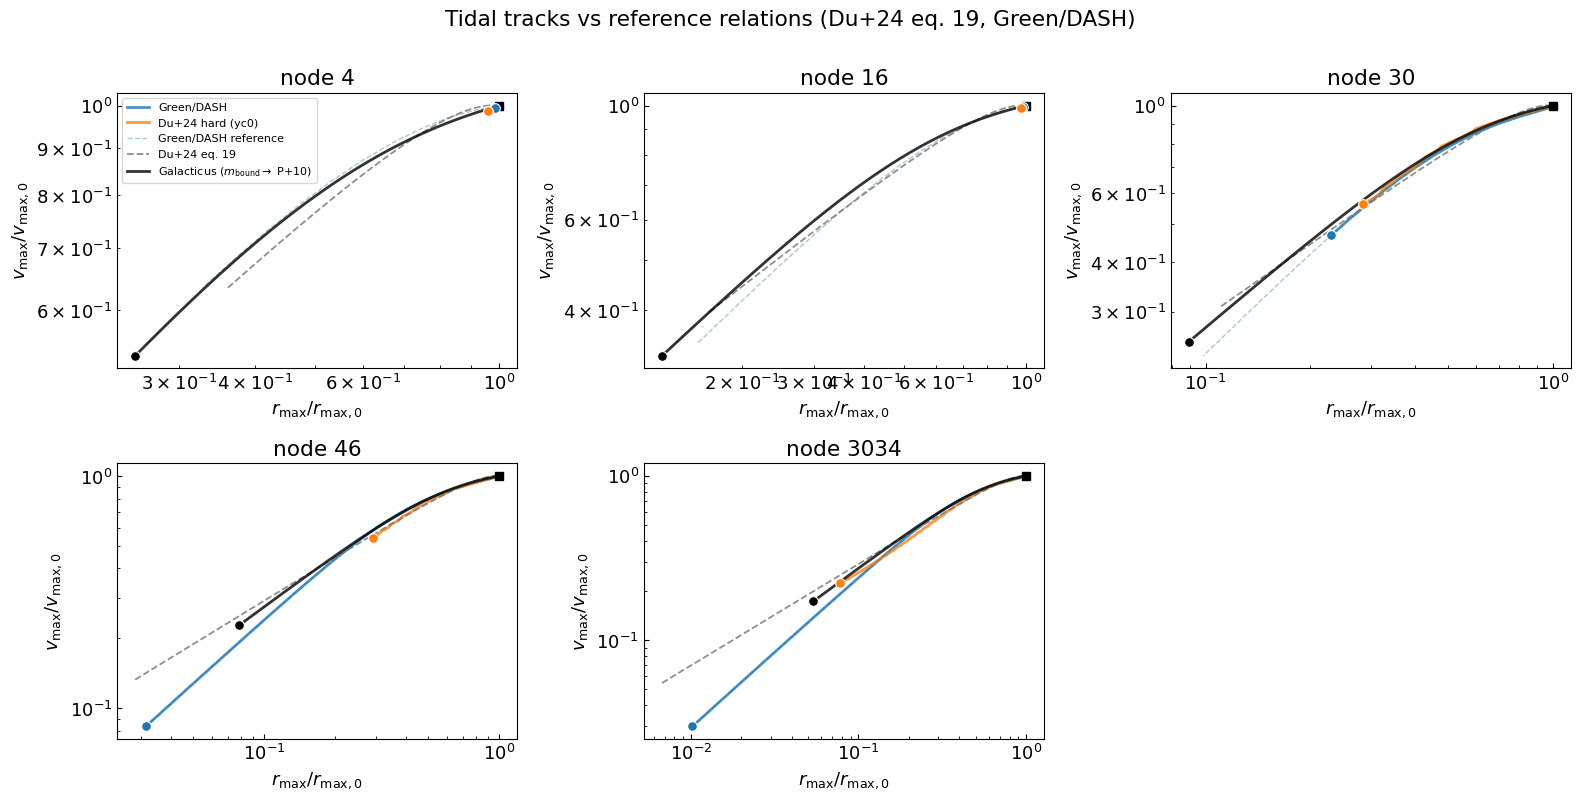

In [7]:
def _fbmin(r):
    m = r.m[np.isfinite(r.m)]
    return m.min() / m[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nid in zip(axes.flat, NODES):
    o = RUNS[nid]; gal = o['gal']
    for r, c, lab in [(o['green'], 'C0', 'Green/DASH'), (o['hard'], 'C1', 'Du+24 hard (yc0)')]:
        g = np.isfinite(r.rmax) & np.isfinite(r.vmax)
        Rr, Vv = r.rmax[g]/r.rmax0, r.vmax[g]/r.vmax0
        ax.plot(Rr, Vv, color=c, lw=2, alpha=0.8, label=lab)
        # mark where the curve terminates (deepest strip) so it's visible even
        # when hidden behind another track
        ax.plot(Rr[-1], Vv[-1], 'o', color=c, ms=7, mec='white', mew=0.8, zorder=6)
    # no-orbit reference tracks, clipped to the bound-fraction range the actual
    # evolutions span -- thin/faint so the methods and Galacticus read as primary
    fb_lo = min(_fbmin(o['green']), _fbmin(o['hard']),
                float(np.nanmin(gal['m_anchor'])))
    _, R_gd, V_gd = gc.green_dash_track(o['ic']['c_sub'], o['ic']['Mvir'], fb_min=fb_lo)
    ax.plot(R_gd, V_gd, '--', color='C0', lw=1, alpha=0.4, label='Green/DASH reference')
    R_du, V_du = gc.du24_nfw_track(np.logspace(np.log10(fb_lo), 0, 200))
    ax.plot(R_du, V_du, '--', color='0.45', lw=1.3, alpha=0.8, label='Du+24 eq. 19')
    # Galacticus: its bound-mass ledger through the Penarrubia2010 tidal track
    # (the run keeps the NFW frozen and m_bound a decoupled scalar; this is where
    # that history would sit structurally)
    ax.plot(gal['track_R'], gal['track_V'], '-', color='k', lw=2, alpha=0.8,
            label='Galacticus ($m_\\mathrm{bound}\\to$ P+10)')
    ax.plot(gal['track_R'][-1], gal['track_V'][-1], 'o', color='k', ms=7,
            mec='white', mew=0.8, zorder=6)
    ax.plot(1, 1, 'ks', ms=6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f"node {nid}"); ax.set_xlabel('$r_\\mathrm{max}/r_\\mathrm{max,0}$')
    ax.set_ylabel('$v_\\mathrm{max}/v_\\mathrm{max,0}$')
for ax in axes.flat[len(NODES):]:
    ax.axis('off')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Tidal tracks vs reference relations (Du+24 eq. 19, Green/DASH)', y=1.0)
fig.tight_layout()
plt.show()